# Tanzania Climate Data EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("../data/tanzania.csv")
df["Country"] = "Tanzania"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


In [3]:
df = df.replace(-999, np.nan)

In [4]:
df.duplicated().sum()

np.int64(0)

### Duplicate Analysis

- No rows with duplicates were found

In [5]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


### Summary Statistics Interpretation

The dataset contains 4,108 daily observations from 2015 to 2026.

Temperature:
- The average temperature (T2M) is approximately 26.8 degrees, with values ranging from 22.68 to 29.97.
- Maximum daily temperature is 33.93 degree, while minimum temperature is around 20.03 degree.
- This indicates a warm and stable climate with low variability.

Precipitation:
- The average daily precipitation is 3.74 mm, and the maximum is 122.65 mm.
- The median (0.64 mm) is much lower than the mean, suggesting there are many dry days and few days with heavy rain.

Humidity:
- Average humidity is 77.1%, but it ranges from 60% to 91%, indicating relatively high and stable moisture levels.

Wind:
- Average wind speed is about 4.1 m/s, indicating moderate wind conditions.

Overall the dataset suggests that the region experiences consistently warm temperatures, moderately high humidity, and occasional heavy rainfall with generally stable weather conditions.

In [6]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

There are no rows with missing values

In [7]:
missing_percent = df.isna().mean() * 100
missing_percent
missing_percent[missing_percent > 5]

Series([], dtype: float64)

### Missing Value Analysis

- After replacing -999 with NaN, no missing values were found in any column.

- The percentage of missing values across all columns is 0%, meaning no more than 5% missing values.

- This suggests the dataset is complete, and no imputation or row removal is required.

In [8]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
z_scores = df[cols].apply(zscore)
outliers = (np.abs(z_scores) > 3)

rows_with_outliers = outliers.any(axis=1).sum()
rows_with_outliers

np.int64(97)

### Outlier Analysis

Using the Z-score method (|Z| > 3), 97 rows with outliers were found.

Descision: Outliers should be kept in the dataset because they are likely real events (heavy rainfall or unusually high/low temperature) and not errors.

### Missing Value Handling

No missing values were found in the dataset so applying forward-fill or dropping rows was unnecessary.

In [9]:
df.to_csv("../data/tanzania_clean.csv", index=False)

In [10]:
monthly_temp = df.groupby("Month")["T2M"].mean()
monthly_temp

Month
1     27.822742
2     28.112920
3     28.155323
4     27.416061
5     26.224340
6     25.267636
7     24.912581
8     25.203783
9     25.864515
10    26.832962
11    27.537394
12    28.034487
Name: T2M, dtype: float64

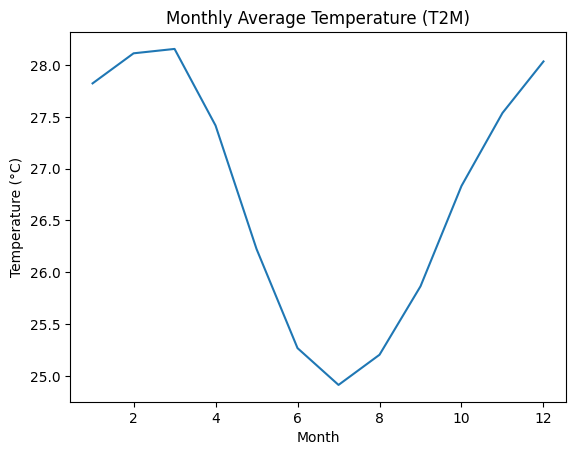

In [11]:
plt.figure()
monthly_temp.plot()
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

In [12]:
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

warmest_month, coolest_month

(np.int32(3), np.int32(7))

### Monthly Temperature Trend

The temperature shows a fairly stable warm climate with only moderate seasonal fluctuations rather than distinct hot and cold seasons. The warmest period occurs in month 3, while the coolest occurs in month 7. There are no obvious anomalies.

In [13]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()
monthly_rain

Month
1     1711.51
2      887.90
3     2173.38
4     3278.68
5     2147.21
6      402.36
7      187.46
8      144.64
9      203.17
10     921.44
11    1709.42
12    1597.80
Name: PRECTOTCORR, dtype: float64

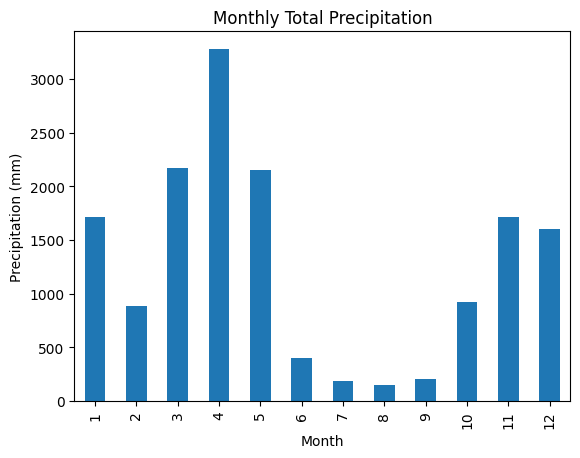

In [14]:
plt.figure()
monthly_rain.plot(kind="bar")
plt.title("Monthly Total Precipitation")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.show()

In [15]:
monthly_rain.sort_values(ascending=False).head(3)

Month
4    3278.68
3    2173.38
5    2147.21
Name: PRECTOTCORR, dtype: float64

### Monthly Precipitation Analysis

The peak rainy months are April, May and July. There is strong seasonal variation in rainfall.

In [16]:
numeric_df = df[[
    "T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE",
    "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"
]]

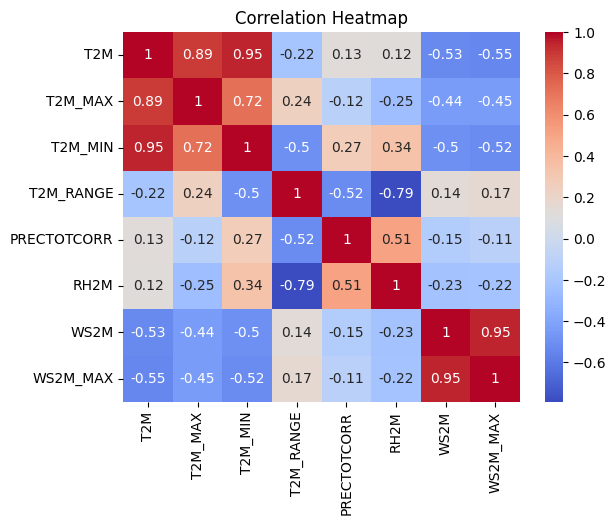

In [17]:
plt.figure()
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

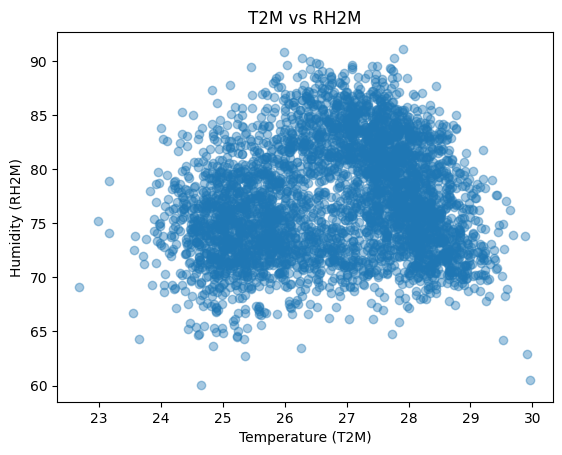

In [18]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"], alpha=0.4)
plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()

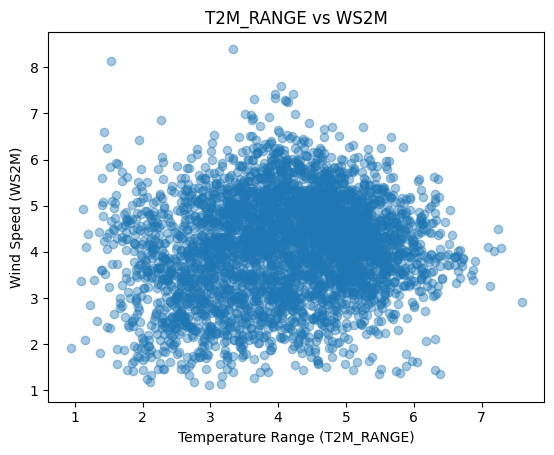

In [19]:
plt.figure()
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.4)
plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range (T2M_RANGE)")
plt.ylabel("Wind Speed (WS2M)")
plt.show()

In [20]:
corr = numeric_df.corr().abs()

top_3 = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
    .head(3)
)

top_3

WS2M  WS2M_MAX    0.951026
T2M   T2M_MIN     0.950399
      T2M_MAX     0.889655
dtype: float64

### Strongest Correlations

The three strongest correlations in the dataset are:

1. WS2M and WS2M_MAX (0.951026)
2. T2M and T2M_MIN (0.950399)
3. T2M and T2M_MAX (0.889655)

Interpretation:
- Daily average wind speed (WS2M) and maximum wind speed (WS2M_MAX) are very strongly correlated, which is expected since they measure related wind conditions.

- Average temperature (T2M) and minimum temperature (T2M_MIN) are very strongly correlated. This indicates that overall daily temperature closely follows nighttime or lower temperature conditions.

- Average temperature (T2M) and maximum temperature (T2M_MAX) are also strongly correlated, suggesting that hotter days consistently increase both average and peak temperatures.

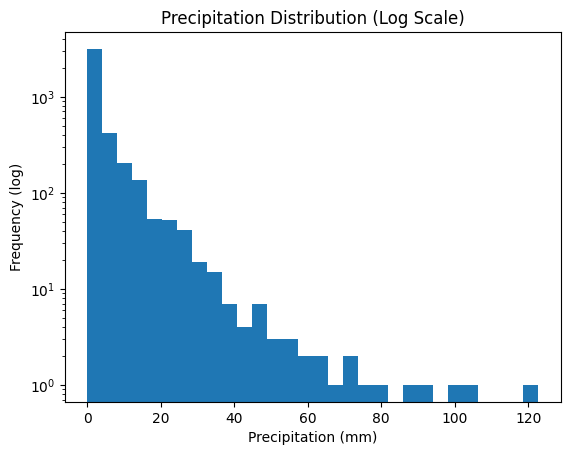

In [21]:
plt.figure()
plt.hist(df["PRECTOTCORR"], bins=30, log=True)
plt.title("Precipitation Distribution (Log Scale)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency (log)")
plt.show()

### Precipitation Distribution

The distribution of daily precipitation is skewed, with most values clustered near zero and only a few extreme rainfall events.

This indicates that:
- Most days are dry or experience very low rainfall
- Heavy rainfall events occur occasionally


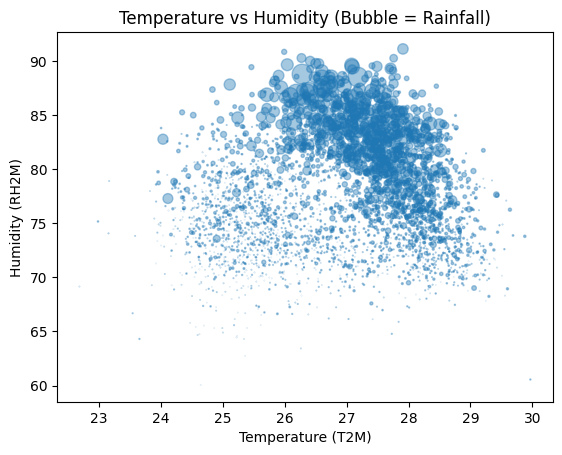

In [22]:
plt.figure()

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 2,
    alpha=0.4
)

plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()

### Bubble Chart Analysis

The bubble chart shows the relationship between temperature (T2M) and humidity (RH2M), with rainfall represented by bubble size.

Observations:
- Higher rainfall values (larger bubbles) appear at higher humidity levels.
- Rainfall is not evenly distributed but concentrated in specific climate conditions.
